In [4]:
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
sns.set_style('white')

In [6]:
# Read in the shapefile for Maryland
shapefile_path = '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023'
gdf = gpd.read_file(shapefile_path, columns=['GEOID', 'STATEFP', 'geometry']).to_crs('WGS84')
gdf = gdf[gdf['STATEFP'] == '24'][['GEOID', 'geometry']].reset_index(drop=True)
gdf.head()

,GEOID,geometry
0,24001,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
1,24003,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3..."
2,24005,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ..."
3,24009,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3..."
4,24011,"POLYGON ((-75.72279 38.82985, -75.72236 38.824..."


In [7]:
# Read in the census data
census_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/census/data/acs_5yr_2023/county/Maryland/*.csv'))
dataframes = []
df = None
for i, census_file in enumerate(census_files):
    if i != len(census_files) - 1:
        df = pd.read_csv(census_file)
        ncols = len(df.columns)
        df = pd.read_csv(census_file, usecols=range(ncols - 4))
        dataframes.append(df)
    else:
        df = pd.read_csv(census_file)
        dataframes.append(df)
df_census = pd.concat(dataframes, axis=1)

# Clean up the census data
df_census.drop(columns=['Unnamed: 0'], inplace=True) # Drop duplicate index column
df_census['GEOID'] = df_census['GEO_ID'].str.slice(-5) # Extract the shortened GEOID from the GEO_ID column
df_census.drop(columns=['GEO_ID'], inplace=True) # Drop the original GEO_ID column
cols = df_census.columns.tolist()
new_order = cols[-3:] + cols[:-3]
df_census = df_census[new_order] # Reorder columns
df_census.rename(columns={'state': 'STATEFP', 'county': 'COUNTYFP'}, inplace=True) # Rename columns

# Split estimates and margins of error into separate DataFrames
retain_columns = ['GEOID', 'NAME', 'STATEFP', 'COUNTYFP']
df_census_est = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('E')]].copy()
df_census_moe = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('M')]].copy()
df_census_est.columns = df_census_est.columns.str[:-1]
df_census_moe.columns = df_census_moe.columns.str[:-1]
df_census_est = pd.concat([df_census[retain_columns], df_census_est], axis=1)
df_census_moe = pd.concat([df_census[retain_columns], df_census_moe], axis=1)

df_census_est.head()

,GEOID,NAME,STATEFP,COUNTYFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,B01001_006,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
0,24001,"Allegany County, Maryland",24,1,67762,35357,1588,1900,1671,1093,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
1,24003,"Anne Arundel County, Maryland",24,3,590936,292506,18141,18728,19943,11393,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
2,24005,"Baltimore County, Maryland",24,5,849586,404133,24970,26150,27069,16648,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
3,24009,"Calvert County, Maryland",24,9,93791,46707,2543,3457,3108,2085,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
4,24011,"Caroline County, Maryland",24,11,33406,16442,1048,1318,939,733,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


In [8]:
# Read in aggregated data
agg_filenames = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/aggregated/county/Maryland/ifs/0.125/t2m/00/24/*/*/*.csv'))
dfs = []
for filename in agg_filenames:
    df = pd.read_csv(filename, index_col=0)
    df['GEOID'] = df['GEOID'].astype(str)
    df['time'] = pd.to_datetime(df['time'])
    df['Year'] = [d.strftime('%Y') for d in df['time']]
    df['Month'] = [d.strftime('%m') for d in df['time']]
    df['Day'] = [d.strftime('%d') for d in df['time']] 
    df.loc[df['Month'].isin(['12', '01', '02']), 'Season'] = 'DJF'
    df.loc[df['Month'].isin(['03', '04', '05']), 'Season'] = 'MAM'
    df.loc[df['Month'].isin(['06', '07', '08']), 'Season'] = 'JJA'
    df.loc[df['Month'].isin(['09', '10', '11']), 'Season'] = 'SON'
    df = pd.concat([df, df_census_est.copy().iloc[:,1:]], axis=1)
    dfs.append(df)
MD_error = pd.concat(dfs)
MD_error.reset_index(inplace=True, drop=True)

In [9]:
(MD_error['time'].min().strftime('%Y-%m-%d-%H'), MD_error['time'].max().strftime('%Y-%m-%d-%H'))

('2016-01-03-00', '2024-11-30-00')

In [10]:
MD_error.head()

,GEOID,time,t2m_abs_error,Year,Month,Day,Season,NAME,STATEFP,COUNTYFP,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
0,24001,2016-01-03,1.516969,2016,01,03,DJF,"Allegany County, Maryland",24,1,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
1,24003,2016-01-03,1.088814,2016,01,03,DJF,"Anne Arundel County, Maryland",24,3,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
2,24005,2016-01-03,0.957353,2016,01,03,DJF,"Baltimore County, Maryland",24,5,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
3,24009,2016-01-03,0.331070,2016,01,03,DJF,"Calvert County, Maryland",24,9,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
4,24011,2016-01-03,0.414652,2016,01,03,DJF,"Caroline County, Maryland",24,11,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


In [242]:
error_stats = pd.DataFrame(MD_error['t2m_abs_error'].describe())
error_stats

,t2m_abs_error
count,75360.000000
mean,1.305818
std,0.912704
min,0.019265
25%,0.598989
50%,1.103690
75%,1.807507
max,10.913544


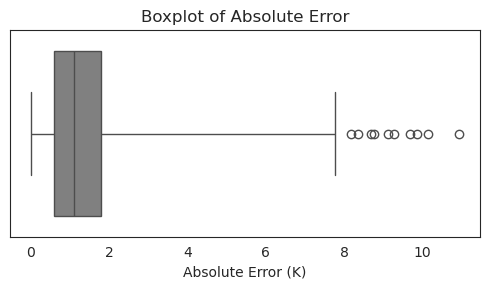

In [250]:
plt.figure(figsize=(5,3))
sns.boxplot(data=MD_error, x='t2m_abs_error', whis=5, color='grey')
plt.xlabel('Absolute Error (K)')
plt.title('Boxplot of Absolute Error')
plt.tight_layout()
plt.show()

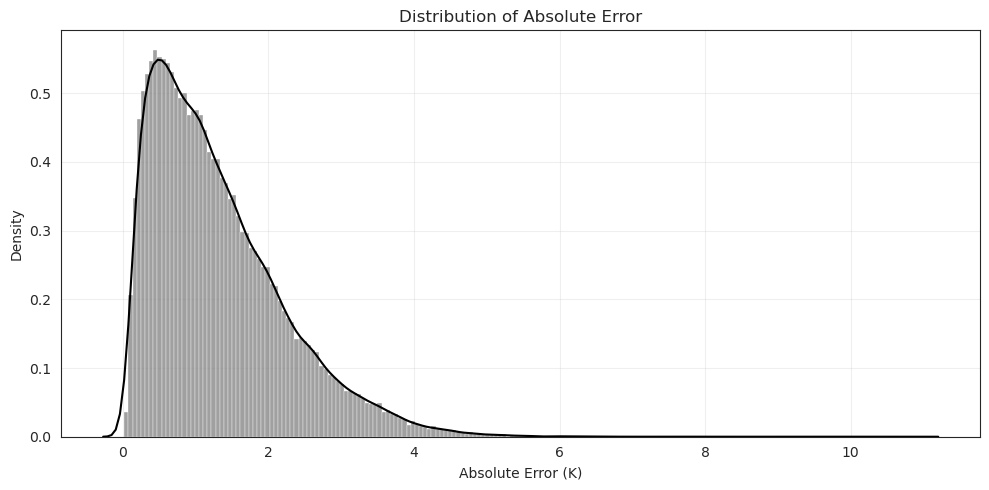

In [221]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, x='t2m_abs_error', c='k')
sns.histplot(data=MD_error, x='t2m_abs_error', stat='density', color='grey')
plt.title('Distribution of Absolute Error')
plt.xlabel('Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
MD_error['log_t2m_abs_error'] = np.log(MD_error['t2m_abs_error'])

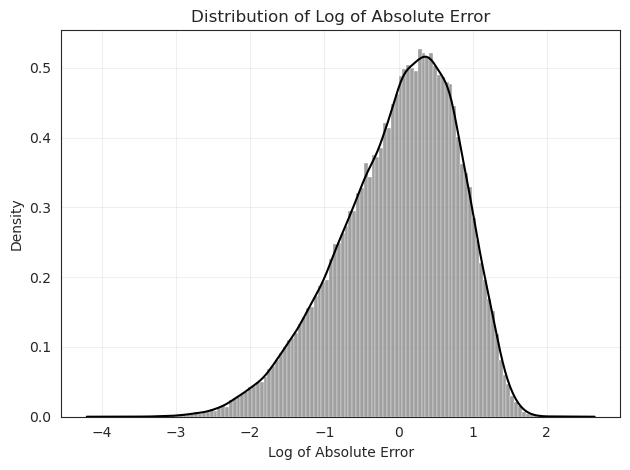

In [222]:
sns.kdeplot(data=MD_error, x='log_t2m_abs_error', c='k')
sns.histplot(data=MD_error, x='log_t2m_abs_error', color='grey', stat='density')
plt.title('Distribution of Log of Absolute Error')
plt.xlabel('Log of Absolute Error')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

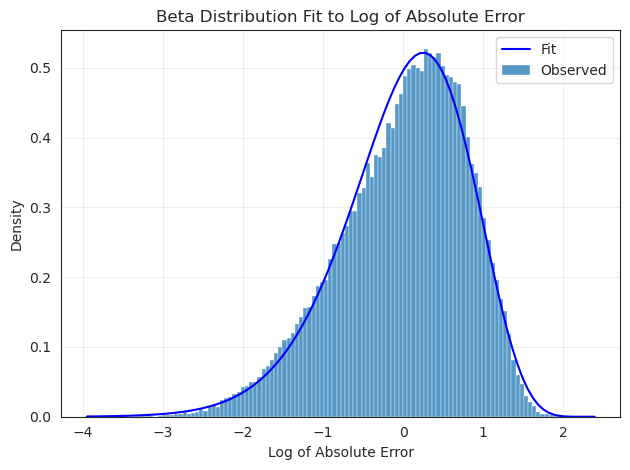

In [220]:
# Fit Log of Absolute Error to Beta Distribution
a, b, loc, scale = stats.beta.fit(MD_error['log_t2m_abs_error'])
x = np.linspace(MD_error['log_t2m_abs_error'].min(), MD_error['log_t2m_abs_error'].max(), 100)
p = stats.beta.pdf(x, a, b, loc=loc, scale=scale)
plt.plot(x, p, 'b', label='Fit')
sns.histplot(data=MD_error, x='log_t2m_abs_error', stat='density', label='Observed')
plt.title('Beta Distribution Fit to Log of Absolute Error')
plt.xlabel('Log of Absolute Error')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [243]:
error_stats_by_year = pd.DataFrame(MD_error.groupby('Year')['t2m_abs_error'].describe())
error_stats_by_year

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2016,8448.0,1.226706,0.903575,0.028923,0.525136,0.998594,1.706273,6.512156
2017,8448.0,1.326968,0.965778,0.031932,0.585553,1.093966,1.803122,5.445300
2018,8424.0,1.420096,0.968099,0.019265,0.651197,1.232560,1.978053,6.188012
2019,8472.0,1.397042,0.909793,0.054724,0.675222,1.225900,1.930693,6.006013
2020,8424.0,1.359134,0.924885,0.060832,0.669337,1.170060,1.857171,10.913544
2021,8448.0,1.312193,0.958692,0.044103,0.560391,1.066440,1.861136,5.993998
2022,8472.0,1.286489,0.870430,0.042364,0.617564,1.108154,1.764372,7.192492
2023,8472.0,1.254134,0.839184,0.037657,0.622321,1.078311,1.699612,6.037609
2024,7752.0,1.157822,0.825800,0.049304,0.512414,0.958960,1.626283,6.393770


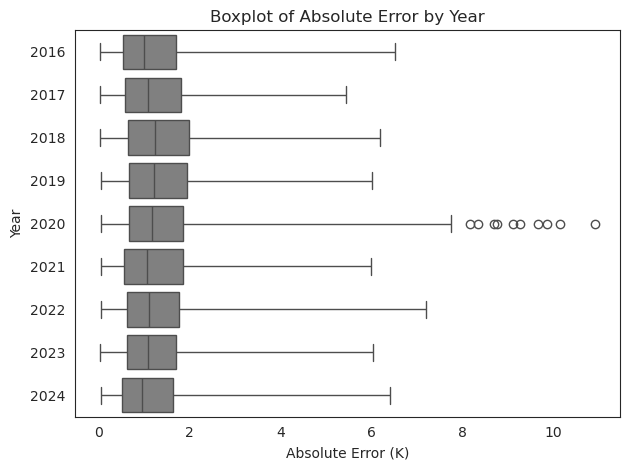

In [251]:
sns.boxplot(data=MD_error, x='t2m_abs_error', y='Year', whis=5, color='grey')
plt.xlabel('Absolute Error (K)')
plt.title('Boxplot of Absolute Error by Year')
plt.tight_layout()
plt.show()

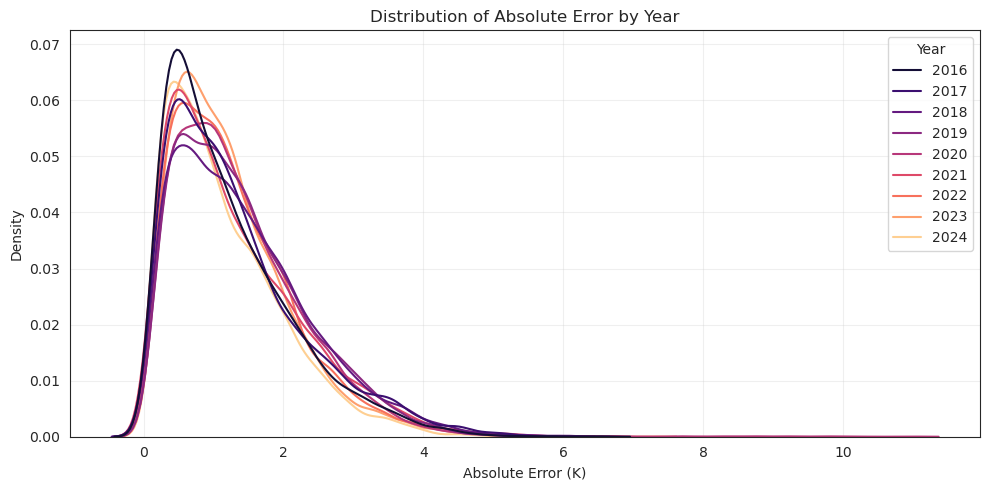

In [267]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='Year', x='t2m_abs_error', palette='magma')
plt.title('Distribution of Absolute Error by Year')
plt.xlabel('Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

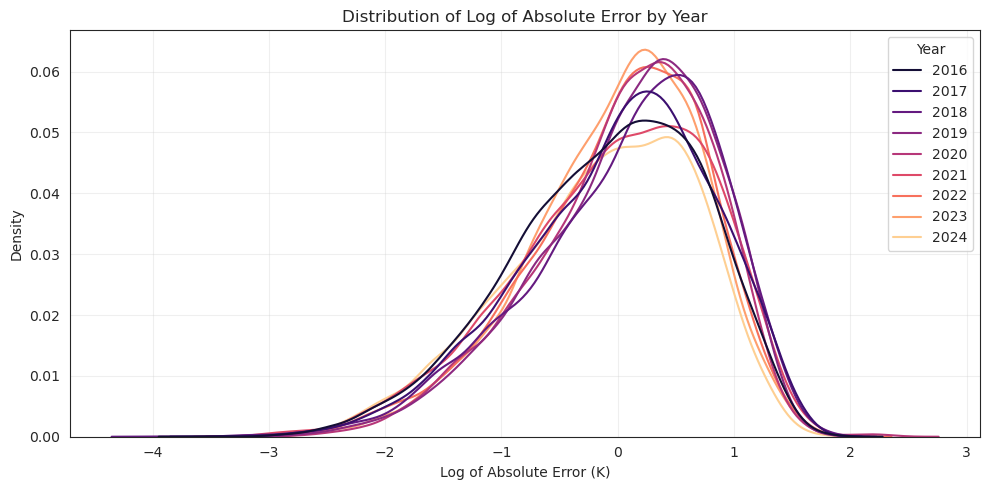

In [273]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='Year', x='log_t2m_abs_error', palette='magma')
plt.title('Distribution of Log of Absolute Error by Year')
plt.xlabel('Log of Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [279]:
error_stats_by_month = pd.DataFrame(MD_error.groupby('Month')['t2m_abs_error'].describe())
error_stats_by_month

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
01,6432.0,1.320864,0.809700,0.019265,0.669177,1.229453,1.842319,5.144168
02,5832.0,1.547232,1.074302,0.028923,0.725752,1.350526,2.127099,10.913544
03,6480.0,1.729993,1.054794,0.051314,0.833957,1.626808,2.462234,6.332714
04,6264.0,1.887550,1.158734,0.040053,0.949055,1.734620,2.684118,7.192492
05,6480.0,1.651504,1.055612,0.049311,0.769547,1.493307,2.338667,6.188012
06,6240.0,1.368203,0.818518,0.073169,0.702731,1.237569,1.894770,6.393770
07,6456.0,1.188998,0.759756,0.072333,0.616327,1.048232,1.577707,6.037609
08,6480.0,1.146904,0.675851,0.037369,0.632746,1.044078,1.550784,5.581041
09,6216.0,0.866308,0.570794,0.052101,0.435955,0.748647,1.162716,5.084526


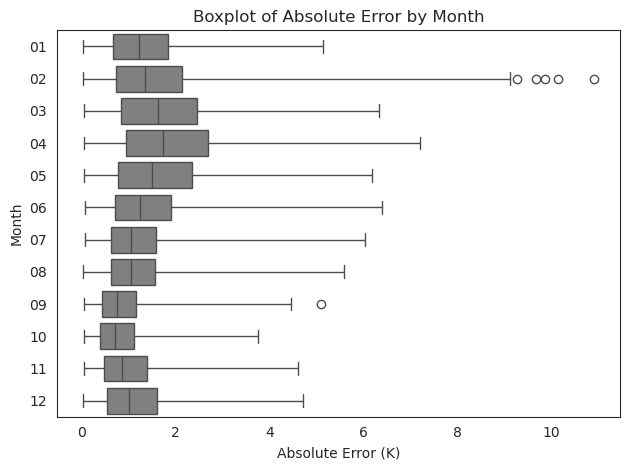

In [280]:
sns.boxplot(data=MD_error, x='t2m_abs_error', y='Month', whis=5, color='grey')
plt.xlabel('Absolute Error (K)')
plt.title('Boxplot of Absolute Error by Month')
plt.tight_layout()
plt.show()

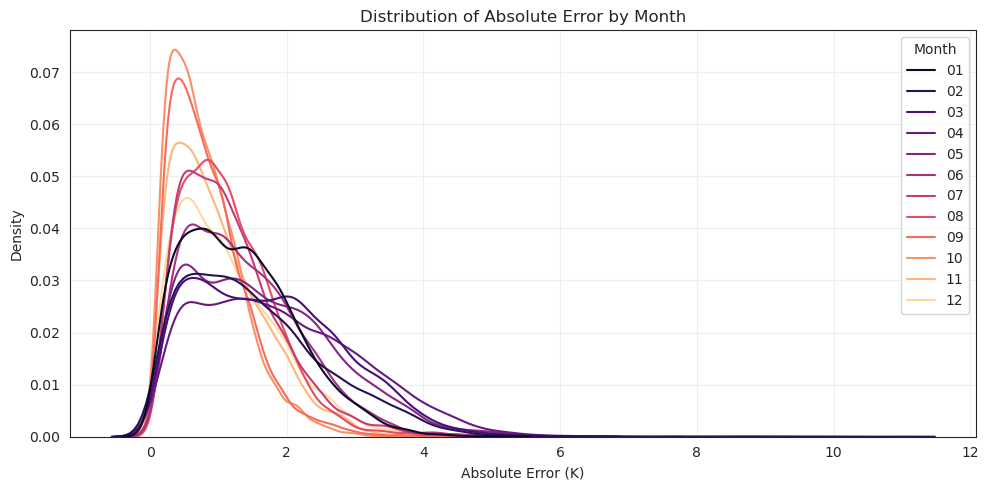

In [284]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='Month', x='t2m_abs_error', legend=True, palette='magma')
plt.title('Distribution of Absolute Error by Month')
plt.xlabel('Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

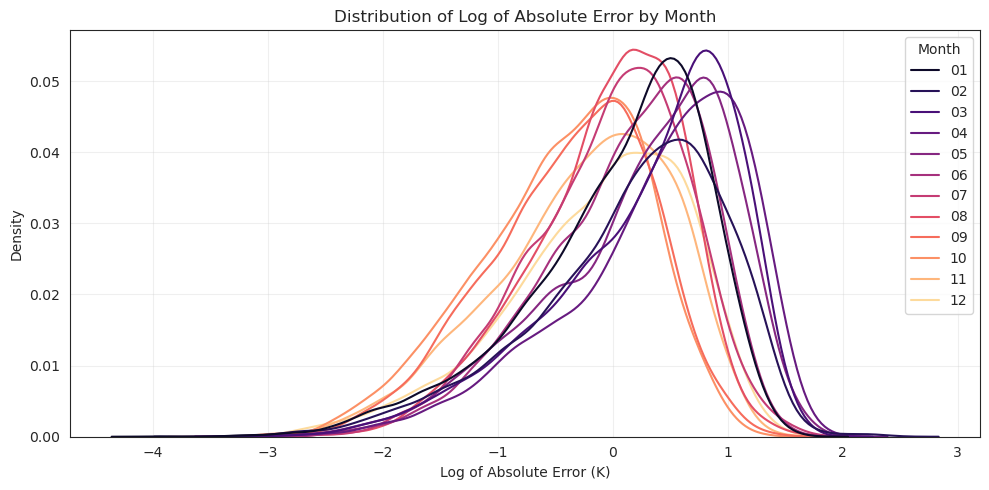

In [285]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='Month', x='log_t2m_abs_error', legend=True, palette='magma')
plt.title('Distribution of Log of Absolute Error by Month')
plt.xlabel('Log of Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [238]:
error_stats_by_season = pd.DataFrame(MD_error.groupby('Season')['t2m_abs_error'].describe())
error_stats_by_season

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
DJF,18024.0,1.337193,0.903316,0.019265,0.636443,1.176995,1.853678,10.913544
JJA,19176.0,1.233088,0.758782,0.037369,0.647887,1.099448,1.664003,6.393770
MAM,19224.0,1.754875,1.094332,0.040053,0.845261,1.614553,2.492812,7.192492
SON,18936.0,0.893717,0.599153,0.042364,0.431735,0.766709,1.220580,5.084526


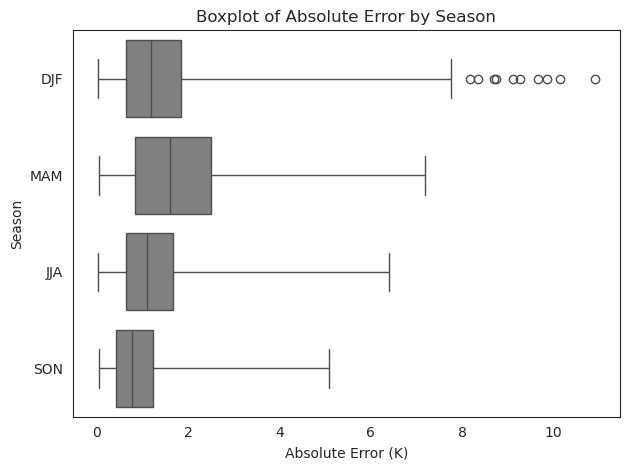

In [275]:
sns.boxplot(data=MD_error, x='t2m_abs_error', y='Season', whis=5, color='grey')
plt.xlabel('Absolute Error (K)')
plt.title('Boxplot of Absolute Error by Season')
plt.tight_layout()
plt.show()

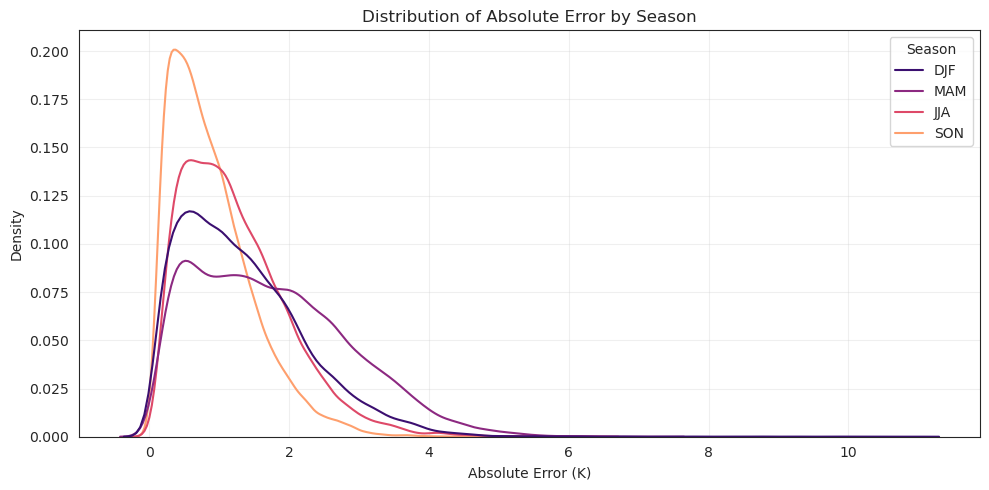

In [277]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='Season', x='t2m_abs_error', legend=True, palette='magma')
plt.title('Distribution of Absolute Error by Season')
plt.xlabel('Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

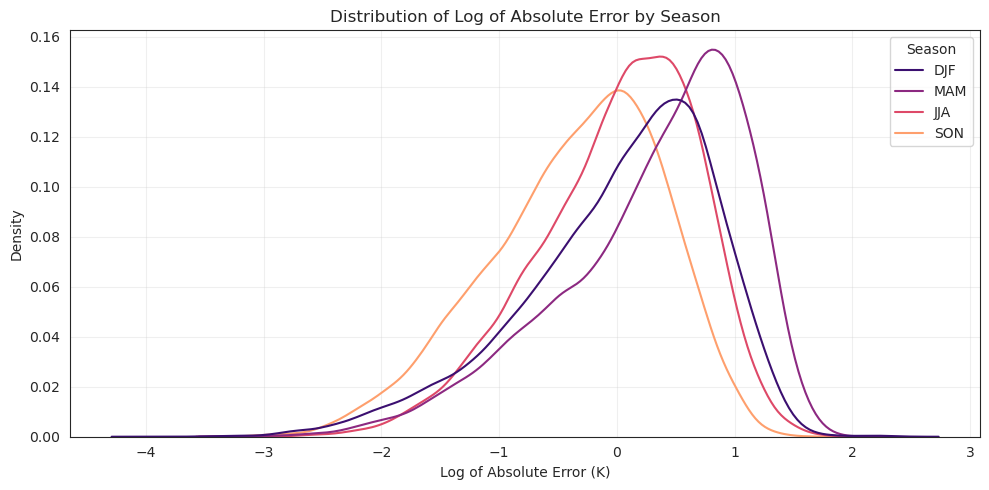

In [278]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='Season', x='log_t2m_abs_error', legend=True, palette='magma')
plt.title('Distribution of Log of Absolute Error by Season')
plt.xlabel('Log of Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
error_stats_by_geoid = pd.DataFrame(MD_error.groupby('GEOID')['t2m_abs_error'].describe())
error_stats_by_geoid

,count,mean,std,min,25%,50%,75%,max
GEOID,,,,,,,,
24001,3140.0,1.612778,1.078838,0.057745,0.754651,1.388275,2.216336,6.210293
24003,3140.0,1.230282,0.851030,0.046807,0.566987,1.035417,1.697974,10.913544
24005,3140.0,1.442448,0.945308,0.031932,0.690769,1.246974,1.988044,6.680454
24009,3140.0,1.118575,0.787127,0.051113,0.524560,0.935685,1.532554,9.662902
24011,3140.0,1.258657,0.891752,0.042364,0.552508,1.083685,1.765024,8.342208
24013,3140.0,1.524614,1.022360,0.039877,0.707601,1.332995,2.110703,5.884281
24015,3140.0,1.408209,0.925775,0.037945,0.686491,1.239235,1.939908,9.108469
24017,3140.0,1.226225,0.853029,0.049084,0.571052,1.020410,1.707495,9.262411
24019,3140.0,1.081065,0.722168,0.052722,0.526520,0.920212,1.472215,6.179292


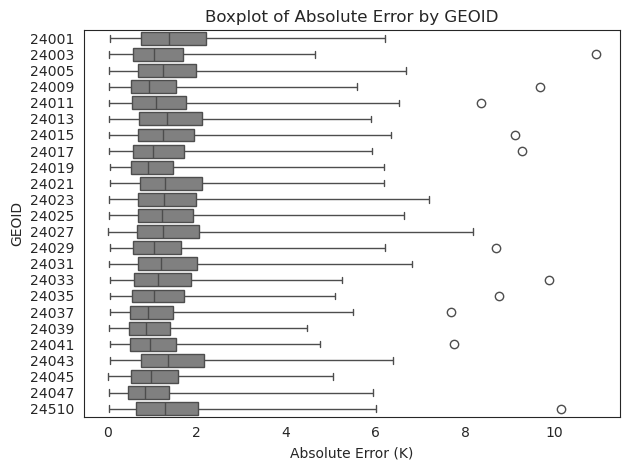

In [274]:
sns.boxplot(data=MD_error, x='t2m_abs_error', y='GEOID', whis=5, color='grey')
plt.xlabel('Absolute Error (K)')
plt.title('Boxplot of Absolute Error by GEOID')
plt.tight_layout()
plt.show()

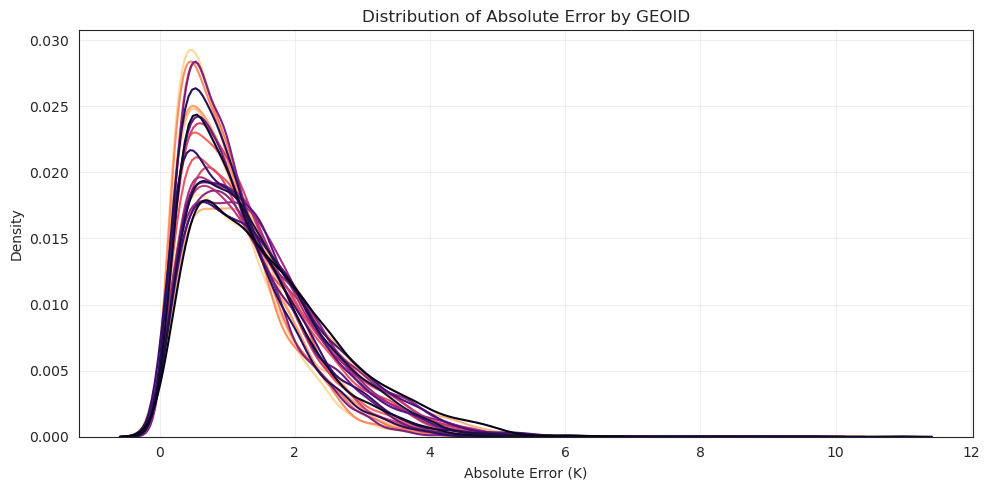

In [266]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='GEOID', x='t2m_abs_error', legend=False, palette='magma')
plt.title('Distribution of Absolute Error by GEOID')
plt.xlabel('Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

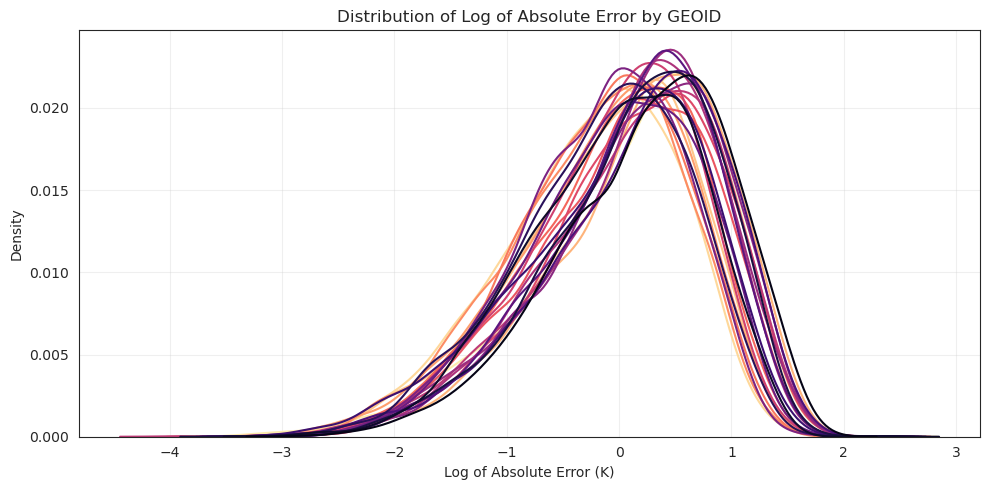

In [271]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=MD_error, hue='GEOID', x='log_t2m_abs_error', legend=False, palette='magma')
plt.title('Distribution of Log of Absolute Error by GEOID')
plt.xlabel('Log of Absolute Error (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

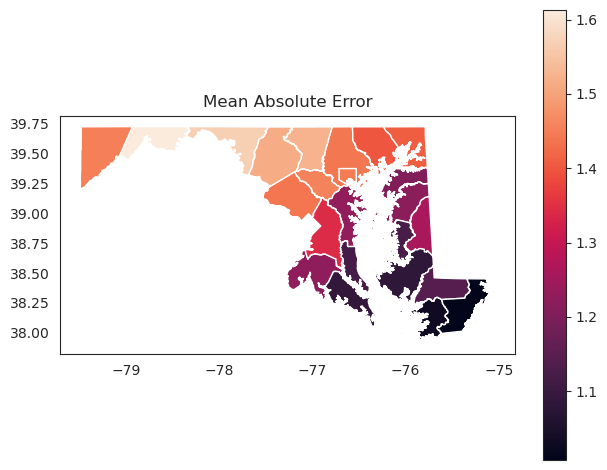

In [14]:
gdf_error = gpd.GeoDataFrame(pd.concat([error_stats_by_geoid.copy(), df_census_est.copy().set_index('GEOID'), gdf.copy().set_index('GEOID')], axis=1))

gdf_error.plot(column='mean', legend=True)
plt.title('Mean Absolute Error')
plt.tight_layout()
plt.show()

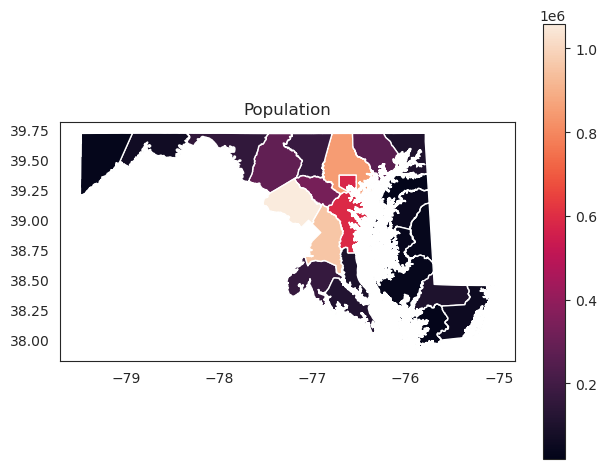

In [15]:
gdf_census = gpd.GeoDataFrame(pd.concat([df_census_est.copy().set_index('GEOID'), gdf.copy().set_index('GEOID')], axis=1))

gdf_census.plot(column='B01001_001', legend=True)
plt.title('Population')
plt.tight_layout()
plt.show()